In [15]:
print("Hello, World!")

Hello, World!


## Task 1: Environment Setup

In [16]:
import pandas
import numpy
import matplotlib
import scipy
import networkx
import plotly

print(pandas.__version__)
print(numpy.__version__)
print(matplotlib.__version__)
print(scipy.__version__)
print(networkx.__version__)
print(plotly.__version__)

3.0.6
2.4.6
3.11.2
1.17.1
3.6.1
6.9.0


## Task 2: Collect and Clean OpenAlex Data


### Task 2.1: Data Acquisition

In [18]:
import requests

In [19]:
url = "https://api.openalex.org/institutions"
params = {
    "search": "Florida State University"
}

response = requests.get(url, params=params)
response.raise_for_status()

data = response.json()

for institution in data["results"]:
    print(institution["display_name"], institution["id"])

Florida State University https://openalex.org/I103163165
Florida A&M University - Florida State University College of Engineering https://openalex.org/I1323276237
University of Florida https://openalex.org/I33213144
Florida State University-Panama https://openalex.org/I115600460
State University System of Florida https://openalex.org/I2801649442
FSU Coastal and Marine Laboratory https://openalex.org/I4402554067


In [20]:
import json
import time
from tqdm.auto import tqdm

fsu_id = "I103163165"

url = "https://api.openalex.org/works"

params = {
    "filter": f"institutions.id:{fsu_id},publication_year:2021-2026",    "per-page": 100,
    "cursor": "*",
    "select": "id,doi,display_name,publication_year,publication_date,type,cited_by_count,authorships,primary_location,open_access,concepts"
}

In [12]:
count = 0

with open("fsu_works_2021_2026.jsonl", "w", encoding="utf-8") as file:
    with tqdm(desc="Downloading FSU works", unit="Works") as progress:
        while(params["cursor"]):
            response = requests.get(url, params=params, timeout=60)
            response.raise_for_status()
            data = response.json()

            works = data["results"]

            if not works:
                break

            for work in works:
                file.write(json.dumps(work) + "\n")

            count += len(works)
            progress.update(len(works))

            params["cursor"] = data["meta"].get("next_cursor")
            time.sleep(0.1)

print("Total works downloaded:", count)

Total works downloaded: 27830


### Task 2.2: Cleaning and Flattening

In [21]:
import json
works = []

with open("fsu_works_2021_2026.jsonl", "r", encoding = "utf-8") as file:
    for line in file:
        works.append(json.loads(line))

print("Total records loaded:", len(works))

Total records loaded: 27830


In [22]:
def flatten_work(work):
    location = work.get("primary_location") or {}
    source = location.get("source") or {}
    open_access = work.get("open_access") or {}

    authorships = work.get("authorships") or []
    authors = [
        (a.get("author") or {}).get("display_name", "")
        for a in authorships
    ]

    concepts = work.get("concepts") or []
    fields = [
        c.get("display_name", "")
        for c in concepts
    ]

    return{
        "openalex_id": work.get("id"),
        "doi": work.get("doi"),
        "title": work.get("display_name"),
        "publication_year": work.get("publication_year"),
        "publication_date": work.get("publication_date"),
        "type": work.get("type"),
        "cited_by_count": work.get("cited_by_count"),
        "venue": source.get("display_name"),
        "venue_id": source.get("id"),
        "is_oa": open_access.get("is_oa"),
        "oa_status": open_access.get("oa_status"),
        "authors": "; ".join(authors),
        "n_authors": len(authors),
        "primary_field": fields[0] if fields else None,
        "fields_all": "; ".join(fields)        
    }

### Task 2.3: Create and Save the DataFrame

In [23]:
import pandas as pd

flattened = [flatten_work(work) for work in works]

df = pd.DataFrame(flattened)

df.head()


,openalex_id,doi,title,publication_year,publication_date,type,cited_by_count,venue,venue_id,is_oa,oa_status,authors,n_authors,primary_field,fields_all
0,https://openalex.org/W2963002078,https://doi.org/10.1093/ptep/ptac097,Review of Particle Physics,2022,2022-08-01,article,6044,Progress of Theoretical and Experimental Physics,https://openalex.org/S4210202364,True,gold,Particle Data Group; Ronald Workman; Volker Bu...,100,Physics,Physics; Particle physics; Higgs boson; Supers...
1,https://openalex.org/W4401211033,https://doi.org/10.1103/physrevd.110.030001,Review of Particle Physics,2024,2024-08-01,article,3592,Physical review. D/Physical review. D.,https://openalex.org/S4210238307,True,hybrid,Sergio Navas; C. Amsler; Th. Gutsche; C. Hanha...,100,Particle physics,Particle physics; Physics; Higgs boson; Supers...
2,https://openalex.org/W3108936441,https://doi.org/10.1080/15548627.2020.1797280,Guidelines for the use and interpretation of a...,2021,2021-01-02,article,2742,Autophagy,https://openalex.org/S102544370,True,bronze,Daniel J. Klionsky; Amal Kamal Abdel‐Aziz; Sar...,100,Autophagy,Autophagy; Biology; Interpretation (philosophy...
3,https://openalex.org/W4387440676,https://doi.org/10.1021/acs.jcim.3c01153,AmberTools,2023,2023-10-08,article,2179,Journal of Chemical Information and Modeling,https://openalex.org/S167262187,True,hybrid,David Andrew Case; Hasan Metin Aktulga; Kellon...,47,Computer science,Computer science; Set (abstract data type); Op...
4,https://openalex.org/W3193988690,https://doi.org/10.1063/5.0055522,Software for the frontiers of quantum chemistr...,2021,2021-08-23,article,1436,The Journal of Chemical Physics,https://openalex.org/S77047749,True,bronze,Evgeny Epifanovsky; Andrew T. B. Gilbert; Xint...,100,Software,Software; Quantum chemistry; Software package;...


In [24]:
df.to_csv("fsu_works_2021_2026.csv", index=False)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 27830
Columns: 15


### Task 2: Sanity Check


In [25]:
print("Original records:", len(works))
print("CSV records:", len(df))
print("Columns:", df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

Original records: 27830
CSV records: 27830
Columns: ['openalex_id', 'doi', 'title', 'publication_year', 'publication_date', 'type', 'cited_by_count', 'venue', 'venue_id', 'is_oa', 'oa_status', 'authors', 'n_authors', 'primary_field', 'fields_all']

Missing values:
openalex_id            0
doi                  248
title                 11
publication_year       0
publication_date       0
type                   0
cited_by_count         0
venue               1483
venue_id            1483
is_oa                  0
oa_status              0
authors                0
n_authors              0
primary_field       1213
fields_all             0
dtype: int64


In [26]:
check_params = {
    "filter": f"institutions.id:{fsu_id},publication_year:2021-2026",
    "group_by": "publication_year",
    "per-page": 100
}

response = requests.get(
    "https://api.openalex.org/works",
    params=check_params,
    timeout=60
)
response.raise_for_status()

groups = response.json()["group_by"]

api_counts = {
    int(group["key"]): group["count"]
    for group in groups
}

local_counts = df["publication_year"].value_counts().sort_index()
print("OpenAlex counts:", api_counts)
print("\nLocal CSV counts:")
print(local_counts)

OpenAlex counts: {2026: 5420, 2025: 4987, 2024: 4605, 2023: 4389, 2021: 4251, 2022: 4178}

Local CSV counts:
publication_year
2021    4251
2022    4178
2023    4389
2024    4605
2025    4987
2026    5420
Name: count, dtype: int64


In [27]:
comparison = pd.DataFrame({
    "OpenAlex": pd.Series(api_counts),
    "Local CSV": local_counts
}).fillna(0).astype(int)

comparison["Difference"] = (
    comparison["OpenAlex"] - comparison["Local CSV"]
)

print(comparison)

print("\nTotal local records:", len(df))
print("Total OpenAlex records:", sum(api_counts.values()))

      OpenAlex  Local CSV  Difference
2021      4251       4251           0
2022      4178       4178           0
2023      4389       4389           0
2024      4605       4605           0
2025      4987       4987           0
2026      5420       5420           0

Total local records: 27830
Total OpenAlex records: 27830


## Task 3: Descriptive Statistics

In [28]:
import pandas as pd

df = pd.read_csv("fsu_works_2021_2026.csv")

print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 27830
Columns: 15


### Task 3.1: Works by Publication Year

In [29]:
works_by_year = df["publication_year"].value_counts().sort_index()

print(works_by_year)

publication_year
2021    4251
2022    4178
2023    4389
2024    4605
2025    4987
2026    5420
Name: count, dtype: int64


FSU's publication counts generally icnreased from 2021 to 2026, with 2026 being the largest despite the year not even being over yet

### Task 3.2: Top 20 Publication Venues

In [30]:
top_venues = df["venue"].value_counts().head(20)

print(top_venues)

venue
DOE Pacific Northwest National Laboratory (PNNL) Repository    1063
arXiv (Cornell University)                                      897
SSRN Electronic Journal                                         784
Zenodo (CERN European Organization for Nuclear Research)        494
bioRxiv (Cold Spring Harbor Laboratory)                         407
Cambridge University Press eBooks                               357
Springer eBooks                                                 302
Journal of High Energy Physics                                  213
Research Square                                                 198
Innovation in Aging                                             174
Physical review. B./Physical review. B                          174
Cureus                                                          162
Nature Communications                                           142
Physical Review Letters                                         140
Physical Review C                         

The venue ranking excludes publications with missing venue info. 2239 records didnt have a recorded publication venue


The most common venue includes the PNNL repository, followed by arXiv and SSRN electronic journay. Many are repos and preprint platforms instead of just journals. 

### Task 3.3: Citation Statistics

In [31]:
citation_stats = df["cited_by_count"].describe()

print(citation_stats)

count    27830.000000
mean         9.112900
std         57.808599
min          0.000000
25%          0.000000
50%          1.000000
75%          7.000000
max       6044.000000
Name: cited_by_count, dtype: float64


With a mean of 9.13 citations but a median of only 1 citation, there is a small amount of highly cited papers, with most publicatings receiving few citations

### Task 3.4: Top 10 Research Fields

In [32]:
fields_df = df.dropna(subset=["primary_field"])

removed = len(df) - len(fields_df)

print("Records removed:", removed)

field_counts = fields_df["primary_field"].value_counts()

top_fields = field_counts.head(10)

field_percentages = (top_fields / len(fields_df)) * 100

field_summary = pd.DataFrame({
    "Number of Works": top_fields,
    "Percentage (%)": field_percentages
})

print(field_summary)

Records removed: 1213
                       Number of Works  Percentage (%)
primary_field                                         
Medicine                          1549        5.819589
Physics                            921        3.460195
Computer science                   917        3.445167
Psychology                         912        3.426382
Biology                            334        1.254837
Chemistry                          309        1.160912
Materials science                  240        0.901679
Mathematics                        201        0.755156
Business                           175        0.657475
Environmental science              155        0.582335


With a wide range of fields, FSUs research spans multiple disciplines, with medicine being the largest, followed behind a similarly sized computer science, physics, and psychology, with environmental science all the way in the bottom. Percentages are calculated using the 26597 papesrs with a known primary field excluding the ones without any

## Task 4: Static Charts in Matplotlib

In [33]:
import matplotlib.pyplot as plt

### Task 4.1: Distribution of Publications Across Fields

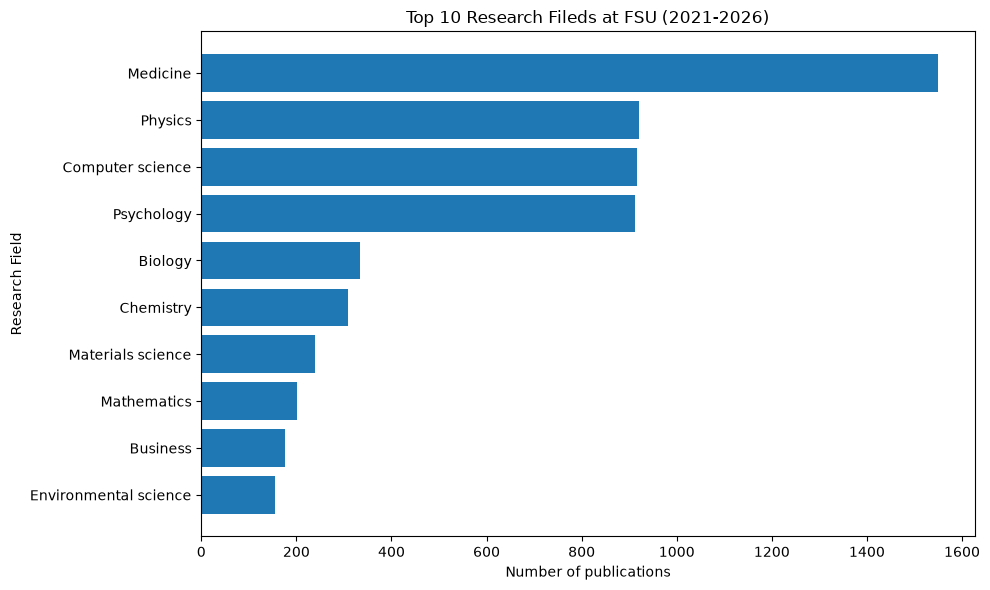

In [34]:
top_10 = (
    df["primary_field"]
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(top_10.index[::-1], top_10.values[::-1])

plt.xlabel("Number of publications")
plt.ylabel("Research Field")
plt.title("Top 10 Research Fileds at FSU (2021-2026)")

plt.tight_layout()
plt.show()

Medicine clearly has the hgihest amount of publications, followed by a nearly tied comp sci, physics, and psych, with it steadily decreasing until the lowest, enviromental science. However, this chart only shows the top 10 fields, so it hidse the remaining fields and doesnt show how it changes over time

### Task 4.2: Field × Year Publication Trends

In [35]:
top_5_fields = (
    df["primary_field"]
    .dropna()
    .value_counts()
    .head(5)
    .index
)

print(top_5_fields)

Index(['Medicine', 'Physics', 'Computer science', 'Psychology', 'Biology'], dtype='str', name='primary_field')


In [36]:
field_year_counts = (
    df[df["primary_field"].isin(top_5_fields)]
    .groupby(["publication_year", "primary_field"])
    .size()
    .unstack(fill_value=0)
)

field_year_counts = field_year_counts.reindex(
    columns=top_5_fields
)

print(field_year_counts)



primary_field     Medicine  Physics  Computer science  Psychology  Biology
publication_year                                                          
2021                   150      138               121         135       57
2022                   191      146               102         122       70
2023                   222      158               119         148       48
2024                   262      167               181         161       36
2025                   352      149               207         179       67
2026                   372      163               187         167       56


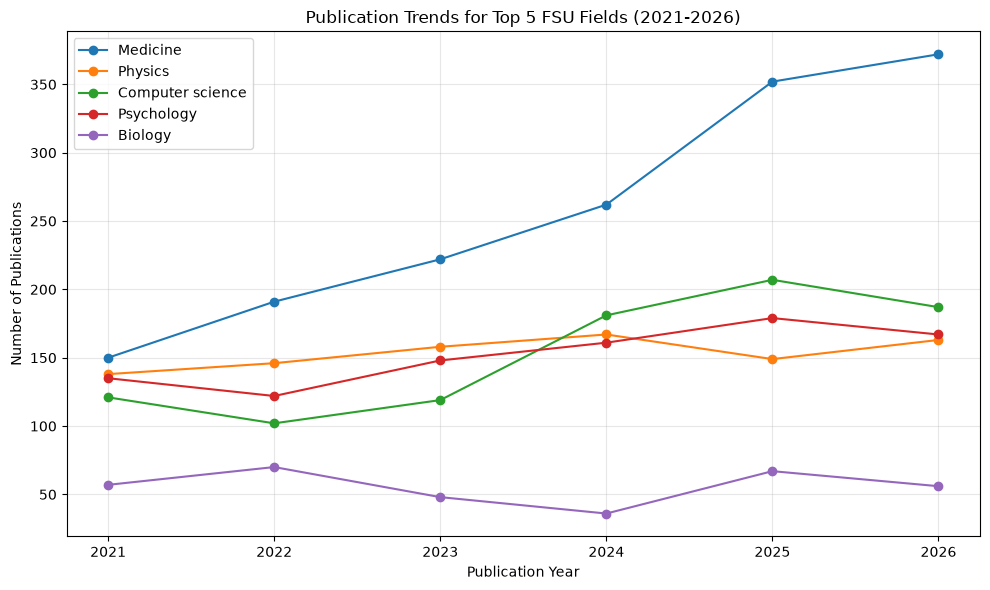

In [37]:
plt.figure(figsize=(10, 6))

for field in top_5_fields:
    plt.plot(
        field_year_counts.index,
        field_year_counts[field],
        marker="o",
        label=field
    )

plt.xlabel("Publication Year")
plt.ylabel("Number of Publications")
plt.title("Publication Trends for Top 5 FSU Fields (2021-2026)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The line chart compares publication trends in the five most common research fields at FSU, letting the reader easily see changes in trends within each fields. However, it only compares the top 5 fields, and since 2026 isnt over yet, it shouldnt be interpreted as final annual totals

### Task 4.3: Citation Count Distribution

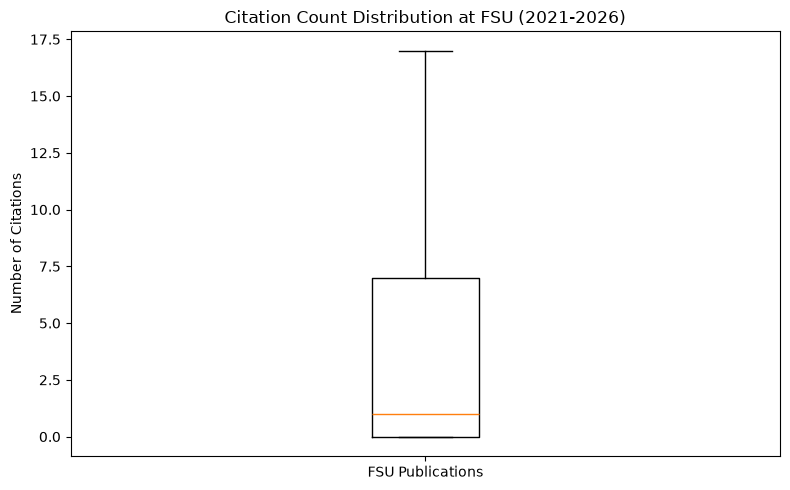

In [38]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    df["cited_by_count"].dropna(),
    showfliers=False
)

plt.ylabel("Number of Citations")
plt.title("Citation Count Distribution at FSU (2021-2026)")
plt.xticks([1], ["FSU Publications"])

plt.tight_layout()
plt.show()

The distribution is strongly skewed with most publications recieving 7 or less, with the median being 1, however, the maximum is very high. The chart hides extreme outliers so the dsitribution is easier to see, so some highly cited papers arent visible

## Task 5: Build and Visualize the Citation Network


### Task 5.1: Build the Network

In [39]:
import pandas as pd
import requests
import time
from tqdm.auto import tqdm

df = pd.read_csv("fsu_works_2021_2026.csv")

print("Total FSU works:", len(df))

Total FSU works: 27830


In [40]:
sample_size = 5000
sample_df = df.sample(
    n = sample_size,
    replace = False,
    random_state = 42
)

print("Sample size:", len(sample_df))
sample_df.head()

Sample size: 5000


,openalex_id,doi,title,publication_year,publication_date,type,cited_by_count,venue,venue_id,is_oa,oa_status,authors,n_authors,primary_field,fields_all
10664,https://openalex.org/W4388367951,https://doi.org/10.1016/j.isatra.2023.11.003,Data-driven NODE based multirate sampled data ...,2023,2023-11-03,article,3,ISA Transactions,https://openalex.org/S89543202,False,closed,Long Zhao; Shihua Li; Rongjie Liu,3,Control theory (sociology),Control theory (sociology); Stability (learnin...
5068,https://openalex.org/W4409509908,https://doi.org/10.3390/agriculture15080865,Influence of Biochar Organic Carbon Compositio...,2025,2025-04-16,article,4,Agriculture,https://openalex.org/S4210202585,True,gold,George K. Osei; Lucy W. Ngatia; Michael D. Aba...,8,Biochar,Biochar; Yield (engineering); Chemistry; Compo...
11502,https://openalex.org/W4410911450,https://doi.org/10.1016/j.ijhm.2025.104317,A health-oriented decision model of insect pro...,2025,2025-05-31,article,2,International Journal of Hospitality Management,https://openalex.org/S148599315,False,closed,Jinha Lee; Woo Gon Kim; Kavitha Haldorai; Chri...,5,Appeal,Appeal; Sensory system; Psychology; Insect; Bu...
4706,https://openalex.org/W4405137307,https://doi.org/10.1016/j.ymben.2024.12.003,Metabolic engineering improves transduction ef...,2024,2024-12-07,article,7,Metabolic Engineering,https://openalex.org/S173328182,True,bronze,Paula Espinoza; Ming Liang Cheng; Carrie Ng; D...,9,Transduction (biophysics),Transduction (biophysics); Cell biology; Biolo...
6241,https://openalex.org/W4221112844,https://doi.org/10.1016/j.ecss.2022.107811,Drifter and dye tracks reveal dispersal proces...,2022,2022-03-07,article,8,Estuarine Coastal and Shelf Science,https://openalex.org/S43867544,True,bronze,Natalie L. Geyer; Dhruv Balwada; Elizabeth Sim...,5,Drifter,Drifter; Oceanography; Phytoplankton; Estuary;...


In [41]:
paper_id = sample_df.iloc[0]["openalex_id"]
work_id = paper_id.rsplit("/", 1)[-1]

response = requests.get(
    f"https://api.openalex.org/works/{work_id}",
    params={
        "select": "id,referenced_works,related_works"
    },
    timeout = 60
)

print("Status:", response.status_code)
print(response.text[:1000])

Status: 200
{"id":"https://openalex.org/W4388367951","referenced_works":["https://openalex.org/W382070501","https://openalex.org/W1575537016","https://openalex.org/W1963907617","https://openalex.org/W1965229818","https://openalex.org/W1998441499","https://openalex.org/W2001829133","https://openalex.org/W2008788675","https://openalex.org/W2012867631","https://openalex.org/W2031096847","https://openalex.org/W2044219402","https://openalex.org/W2063746477","https://openalex.org/W2068483374","https://openalex.org/W2073920306","https://openalex.org/W2081851800","https://openalex.org/W2082568914","https://openalex.org/W2090376497","https://openalex.org/W2134256834","https://openalex.org/W2140974698","https://openalex.org/W2152112251","https://openalex.org/W2162342958","https://openalex.org/W2194775991","https://openalex.org/W2208089304","https://openalex.org/W2419597278","https://openalex.org/W2539264244","https://openalex.org/W2766206045","https://openalex.org/W2789613271","https://openalex.

In [42]:
def get_references(paper_id):
    work_id = paper_id.rsplit("/", 1)[-1]

    for attempt in range(3):
        try:
            response = requests.get(
                f"https://api.openalex.org/works/{work_id}",
                params={
                    "select": "id,referenced_works,related_works"
                },
                timeout=60
            )

            response.raise_for_status()
            return response.json()

        except requests.RequestException:
            if attempt == 2:
                raise


            time.sleep(2 * (attempt + 1))

In [8]:
import csv
import os

output_file = "paper_citation_links_all.csv"
progress_file = "citation_crawl_completed.txt"

completed = set()

if os.path.exists(progress_file):
    with open(progress_file, "r", encoding="utf-8") as f:
        completed = set(line.strip() for line in f)

write_header = not os.path.exists(output_file)

with open(output_file, "a", newline = "", encoding="utf-8") as edge_file, \
    open(progress_file, "a", encoding="utf-8") as progress:

    writer = csv.writer(edge_file)

    if write_header:
        writer.writerow(["source", "target"])

    for paper_id in tqdm(
        sample_df["openalex_id"],
        desc="Fetching references"
    ):
        if paper_id in completed:
           continue

        work = get_references(paper_id)

        source = work["id"]

        for target in work.get("referenced_works") or []:
            writer.writerow([source, target])


        edge_file.flush()

        progress.write(paper_id + "\n")
        progress.flush()

        completed.add(paper_id)

        time.sleep(0.1)

print("Completed sampled papers:", len(completed))



Fetching references:   0%|          | 0/5000 [00:00<?, ?it/s]

Completed sampled papers: 5000


In [43]:
all_edges_df = pd.read_csv(
    "paper_citation_links_all.csv"
)

print("Total citation links:", len(all_edges_df))

all_edges_df.head()

Total citation links: 201516


,source,target
0,https://openalex.org/W4390696040,https://openalex.org/W1511502075
1,https://openalex.org/W4390696040,https://openalex.org/W1539896512
2,https://openalex.org/W4390696040,https://openalex.org/W1568955415
3,https://openalex.org/W4390696040,https://openalex.org/W1755037248
4,https://openalex.org/W4390696040,https://openalex.org/W1771486365


In [44]:
fsu_ids = set(df["openalex_id"])

within_fsu_df = all_edges_df[
    all_edges_df["source"].isin(fsu_ids)
    & all_edges_df["target"].isin(fsu_ids)
].copy()

within_fsu_df.to_csv(
    "paper_citation_links_within_fsu.csv",
    index = False
)

print("All citation links:", len(all_edges_df))
print("FSU-internal links:", len(within_fsu_df))

percentage = (
    len(within_fsu_df) / len(all_edges_df) * 100
    if len(all_edges_df) > 0 else 0
)

print(f"FSU-internal percentage: {percentage:.2f}%")

within_fsu_df.head()

All citation links: 201516
FSU-internal links: 3491
FSU-internal percentage: 1.73%


,source,target
39,https://openalex.org/W4390696040,https://openalex.org/W4221062318
44,https://openalex.org/W4390696040,https://openalex.org/W4320481812
47,https://openalex.org/W4390696040,https://openalex.org/W4366982703
181,https://openalex.org/W4411505139,https://openalex.org/W3136511286
182,https://openalex.org/W4411505139,https://openalex.org/W3169520380


In [45]:
print("All edges columns:", all_edges_df.columns.tolist())
print("Internal edges columns:", within_fsu_df.columns.tolist())

print("All edges:", len(all_edges_df))
print("Internal edges:", len(within_fsu_df))

assert len(within_fsu_df) <= len(all_edges_df)

assert within_fsu_df["source"].isin(fsu_ids).all()
assert within_fsu_df["target"].isin(fsu_ids).all()

print("Verification successful!")

All edges columns: ['source', 'target']
Internal edges columns: ['source', 'target']
All edges: 201516
Internal edges: 3491
Verification successful!


A random sample of 5000 papers was selected, performed without replacement using a fixed random seed of 42 to make the results reproducable. This sample size reduces the number of API rquests, and allows the citation network more managble to visualize. However, it does not capture everyting

### Task 5.2: Static Network Visualization

In [46]:
import networkx as nx
import plotly.graph_objects as go
G = nx.from_pandas_edgelist(
    within_fsu_df,
    source="source",
    target="target",
    create_using=nx.DiGraph()
)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 3762
Edges: 3491


In [47]:
pos = nx.spring_layout(
    G,
    seed = 42
)

In [48]:
edge_x = []
edge_y = []

for source, target in G.edges():
    x0, y0 = pos[source]
    x1, y1 = pos[target]

    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    mode="lines",
    line=dict(width=0.5, color="gray"),
    hoverinfo="none"
)

In [49]:
node_x = []
node_y = []
node_text = []

for node in G.nodes():
    x, y = pos[node]

    node_x.append(x)
    node_y.append(y)
    node_text.append(node)

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode="markers",
    text=node_text,
    hoverinfo="text",
    marker=dict(
        size=5,
        color="#782F40",
        opacity=0.6
    )
)

In [50]:
fig = go.Figure(
    data=[edge_trace, node_trace]
)

fig.update_layout(
    title="FSU Citation Network (2021-2026)",
    showlegend=False,
    xaxis= dict(
        visible=False,
        showgrid=False,
        zeroline=False
    ),
    yaxis=dict(
        visible=False,
        showgrid=False,
        zeroline=False
    ),
    plot_bgcolor="white",
    hovermode="closest"
)

fig.show()

The citation netwrok represents relationships between FSU affiliated publications, each node represents a paper and each edge represnets a citation. It helps shwo the relationship between groups of publications and citations. The dense regions, however, make it hard to see individual relationships without zooming in. Also, since it is based on only 5000 citing papers, it doesnt represent the full dataset

## Task 6: Done outside of notebook

## Task 7: Network Analysis


### Q1: Network Size After Removing Duplicates

In [51]:
import pandas as pd
import networkx as nx

edges = pd.read_csv(
    "backend/data/paper_citation_links_within_fsu.csv"
)

edges = edges.drop_duplicates(subset=["source", "target"])

G = nx.from_pandas_edgelist(
    edges,
    source="source",
    target="target",
    create_using=nx.DiGraph()
)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Network type: Directed")

Nodes: 3762
Edges: 3491
Network type: Directed


The citation network has 3762 unique papers (nodes), and 3491 unique links (edges) after removing the duplcates. I used a directed network, since citations have a direction - one cites another. Each pair is counted as one edge

### Q2: Top 10 Most Cited Papers

In [52]:
papers = pd.read_csv("fsu_works_2021_2026.csv")

citation_counts = dict(G.in_degree())

top_cited = pd.DataFrame(
    citation_counts.items(),
    columns=["openalex_id", "citation_count"]
)

top_cited = top_cited.merge(
    papers[[
        "openalex_id",
        "title",
        "publication_year",
        "venue"
    ]],
    on="openalex_id",
    how="left"
)

top_10=(
    top_cited
    .sort_values(
        "citation_count",
        ascending=False
    )
    .head(10)
)

top_10 = top_10[[
    "title",
    "publication_year",
    "venue",
    "citation_count"
]]

display(top_10)

,title,publication_year,venue,citation_count
257,Electron and photon reconstruction and identif...,2021,Journal of Instrumentation,29
380,Precision luminosity measurement in proton–pro...,2021,The European Physical Journal C,28
142,The CMS Statistical Analysis and Combination T...,2024,Computing and Software for Big Science,15
885,Review of Particle Physics,2022,Progress of Theoretical and Experimental Physics,14
19,Is personality associated with dementia risk? ...,2021,Ageing Research Reviews,11
724,Sense of purpose in life and concurrent loneli...,2022,Journal of Affective Disorders,9
281,Review of Particle Physics,2024,Physical review. D/Physical review. D.,9
442,A Surface Discharge Model for the Design of Su...,2022,IEEE Journal of Emerging and Selected Topics i...,6
1526,Nutraceuticals in Bulk and Dosage Forms: Analy...,2021,Molecular Pharmaceutics,6
725,Sense of meaning and purpose in life and risk ...,2022,Archives of Gerontology and Geriatrics,6


The ten most cited pages are listed above, ranked by in-degree. This is diffrent from OpenAlex's cited_by_count which counts citations from papers worldwide. Since this is jsut FSU-internal links, the citation coutnsa re more limited, and shouldnt be interpeted as each paper's worldwide citation